# Advanced Anomaly Detectors: PaDiM, PatchCore, and OpenVINO

**Purpose.** Document the advanced model family, explain why different categories use different detector architectures, and run the portable advanced artifact that is present in this branch.

**Expected result.** A 15-category model-selection table, saved image/pixel metrics, artifact availability, and a real cable inference through the OpenVINO PatchCore runtime.

**Platform connection.** `ml.inference.live_anomaly_prediction` attempts the configured advanced engine and automatically uses the portable detector if the advanced artifact cannot be loaded.

## Model roles

**PaDiM** models the distribution of normal deep features at each spatial location. A test feature receives a Mahalanobis-style distance from the learned normal distribution, producing both an image anomaly score and a pixel-level anomaly map.

**PatchCore** stores a compact memory bank of representative normal patches. A test patch is anomalous when it is far from its nearest normal patch. Benchmarking selected PatchCore for `cable`, `hazelnut`, and `screw`; the remaining categories retain PaDiM.

**OpenVINO** is an inference format/runtime, not a new detector. It runs an exported trained model efficiently on CPU. In this branch, cable has a complete OpenVINO PatchCore artifact and a learned spatial decision calibrator.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from ml.model_registry import SUPPORTED_CATEGORIES, category_model_spec, is_valid_checkpoint

def load_metadata(category: str) -> dict:
    spec = category_model_spec(category)
    return json.loads(spec.metadata_path.read_text(encoding="utf-8"))

rows = []
for category in SUPPORTED_CATEGORIES:
    spec = category_model_spec(category)
    metadata = load_metadata(category)
    metrics = metadata.get("metrics", {})
    if isinstance(metrics, list):
        metrics = metrics[0] if metrics else {}
    openvino_ready = bool(
        spec.openvino_path
        and spec.openvino_path.exists()
        and spec.openvino_path.with_suffix(".bin").exists()
    )
    rows.append(
        {
            "category": category,
            "selected_detector": spec.model_kind,
            "checkpoint_present": is_valid_checkpoint(spec.checkpoint_path),
            "openvino_present": openvino_ready,
            "image_AUROC": metrics.get("image_AUROC"),
            "image_F1": metrics.get("image_F1Score"),
            "pixel_AUROC": metrics.get("pixel_AUROC"),
            "pixel_F1": metrics.get("pixel_F1Score"),
            "decision_threshold": spec.padim_score_threshold,
        }
    )

advanced_df = pd.DataFrame(rows)
display(advanced_df.style.format({column: "{:.4f}" for column in ["image_AUROC", "image_F1", "pixel_AUROC", "pixel_F1", "decision_threshold"]}, na_rep="n/a"))
print("Selected detector counts:")
display(advanced_df["selected_detector"].value_counts().rename_axis("detector").to_frame("categories"))

,category,selected_detector,checkpoint_present,openvino_present,image_AUROC,image_F1,pixel_AUROC,pixel_F1,decision_threshold
0,bottle,padim,False,False,0.9968,0.9764,0.9820,0.7141,0.5001
1,cable,patchcore,False,True,0.9695,0.9274,0.9815,0.6147,0.5137
2,capsule,padim,False,False,0.8991,0.9554,0.9848,0.4267,0.5009
3,carpet,padim,False,False,0.9952,0.9724,0.9896,0.5656,0.6162
4,grid,padim,False,False,0.9524,0.9298,0.9699,0.4019,0.4871
5,hazelnut,patchcore,False,False,0.9950,0.9640,0.9881,0.6424,0.4815
6,leather,padim,False,False,1.0000,0.9945,0.9897,0.3675,0.5000
7,metal_nut,padim,False,False,0.9839,0.9735,0.9679,0.7619,0.5000
8,pill,padim,False,False,0.8882,0.9459,0.9588,0.5451,0.5235
9,screw,patchcore,False,False,0.9650,0.9407,0.9918,0.3717,0.4163


Selected detector counts:


,categories
detector,
padim,12
patchcore,3


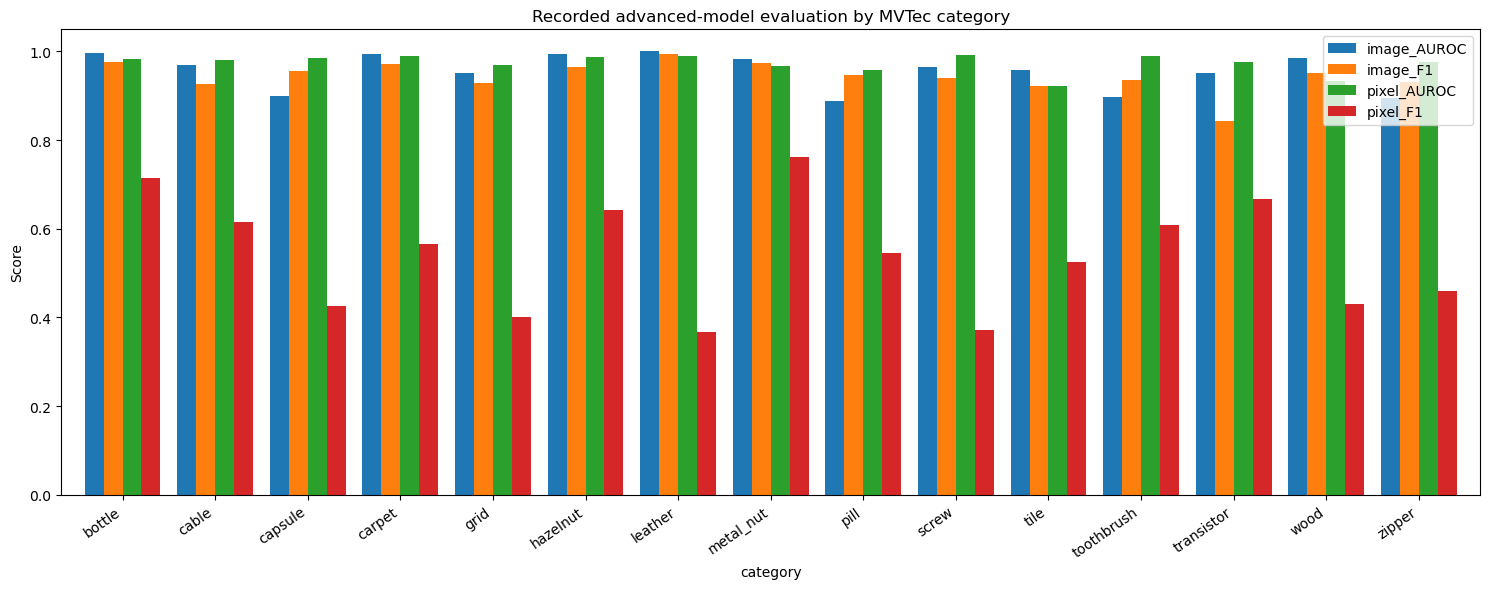

In [3]:
plot_df = advanced_df.set_index("category")[["image_AUROC", "image_F1", "pixel_AUROC", "pixel_F1"]]
ax = plot_df.plot(kind="bar", figsize=(15, 6), width=0.82)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Recorded advanced-model evaluation by MVTec category")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [4]:
from dataclasses import replace
from ml.inference import inspect_image as inspect_image_runtime
from ml.predict import build_inference_config

CATEGORY = "cable"
label, cable_path = first_defect(CATEGORY)
config = build_inference_config(CATEGORY)
spec = category_model_spec(CATEGORY)
openvino_ready = bool(spec.openvino_path and spec.openvino_path.exists() and spec.openvino_path.with_suffix(".bin").exists())
config = replace(
    config,
    use_padim_inference=False,
    use_openvino_inference=openvino_ready,
    openvino_path=spec.openvino_path if openvino_ready else None,
    openvino_calibrator_path=spec.openvino_calibrator_path if openvino_ready else None,
)

advanced_result = inspect_image_runtime(cable_path, config)
compact_result = {
    key: advanced_result[key]
    for key in [
        "model_category", "prediction", "defect_type", "detection_confidence",
        "classification_confidence", "anomaly_score", "defect_area_ratio",
        "severity_score", "severity_level", "pass_fail", "model_used",
        "active_inference_engine", "fallback_used", "fallback_reason",
    ]
}
display(JSON(compact_result))

<IPython.core.display.JSON object>

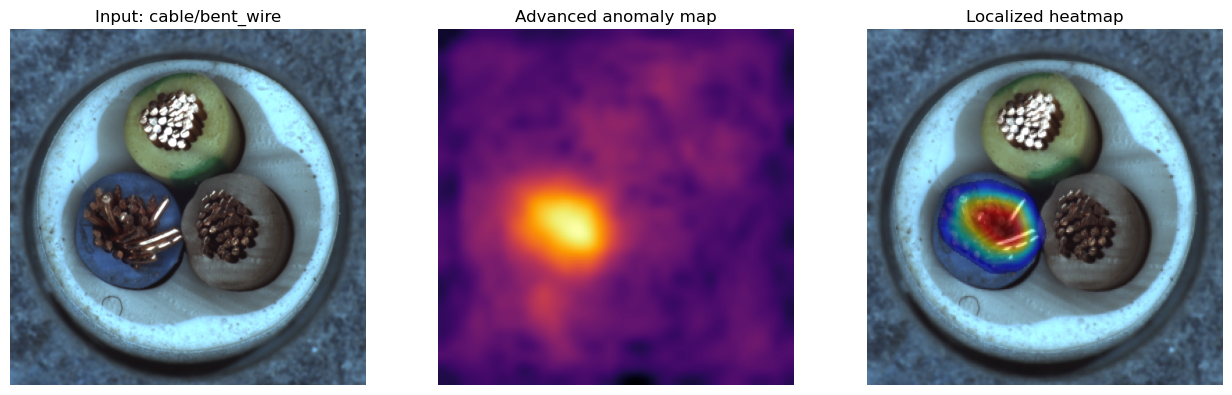

,detector,protocol,folds,samples,decision_threshold,accuracy,precision,recall,specificity,balanced_accuracy,f1,artifact
0,patchcore_openvino_spatial_calibrator,5-fold stratified out-of-fold evaluation on la...,5,150,0.5,0.96,0.9778,0.9565,0.9655,0.961,0.967,models/categories/cable/openvino_calibrator.npz


In [5]:
input_rgb = read_rgb(cable_path)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(input_rgb)
axes[0].set_title(f"Input: cable/{label}")
axes[1].imshow(advanced_result["anomaly_map"], cmap="inferno")
axes[1].set_title("Advanced anomaly map")
axes[2].imshow(cv2.cvtColor(advanced_result["heatmap_image"], cv2.COLOR_BGR2RGB))
axes[2].set_title("Localized heatmap")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

calibration = load_metadata("cable").get("openvino_spatial_calibration", {})
display(pd.DataFrame([calibration]).drop(columns=["defect_subtype_recall", "confusion_matrix"], errors="ignore"))

## Runtime fallback behavior

The registry records the preferred trained architecture for every category. A registry entry alone does not mean its large `.ckpt` file is committed. The runtime checks whether a valid checkpoint or OpenVINO pair exists. When neither can be loaded, it returns the portable detector result and records `fallback_used` and `fallback_reason` for traceability.

## What this demonstrates

- Advanced detector selection is category-specific and based on saved benchmark evidence.
- Image-level metrics evaluate Good/Defective discrimination; pixel-level metrics evaluate localization.
- OpenVINO preserves the trained detector role while making inference practical on CPU.
- Missing large training checkpoints do not break the application because fallback behavior is explicit.